<a href="https://colab.research.google.com/github/harshchaturkar/Mini-Project-repo/blob/main/assignment_27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import make_moons
x, y_test = make_moons(n_samples=500, noise=0.05, random_state=42)

In [ ]:
df = pd.DataFrame(x, columns=["Feature1","Feature2"])
df.head(10)

,Feature1,Feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
5,1.254903,-0.483435
6,1.053851,-0.442690
7,0.031380,1.053012
8,0.620545,0.713096
9,1.787657,-0.142959


In [ ]:
df.shape

(500, 2)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled[:5]

array([[ 0.37512461, -1.40367864],
       [ 0.22681458,  1.13562771],
       [ 0.59544154, -1.49371022],
       [-0.94491835,  1.40974769],
       [-0.24311512,  1.61806199]])

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(x_scaled)

print(df.head())


   Feature1  Feature2  kmeans_cluster
0  0.830586 -0.447733               1
1  0.701678  0.816918               0
2  1.022080 -0.492571               1
3 -0.316765  0.953438               0
4  0.293226  1.057185               0


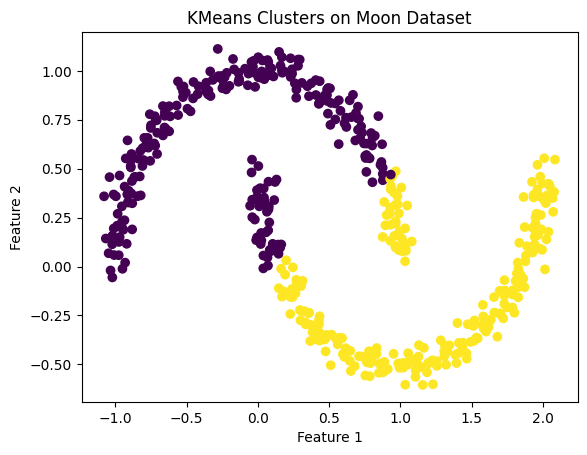

In [ ]:
plt.scatter(df["Feature1"],df["Feature2"],c=df["kmeans_cluster"])

plt.title("KMeans Clusters on Moon Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

model_DBSCAN = DBSCAN(eps=0.3, min_samples=5)

df["dbscan_cluster"] = model_DBSCAN.fit_predict(x_scaled)

print(df.head())

   Feature1  Feature2  kmeans_cluster  dbscan_cluster
0  0.830586 -0.447733               1               0
1  0.701678  0.816918               0               1
2  1.022080 -0.492571               1               0
3 -0.316765  0.953438               0               1
4  0.293226  1.057185               0               1


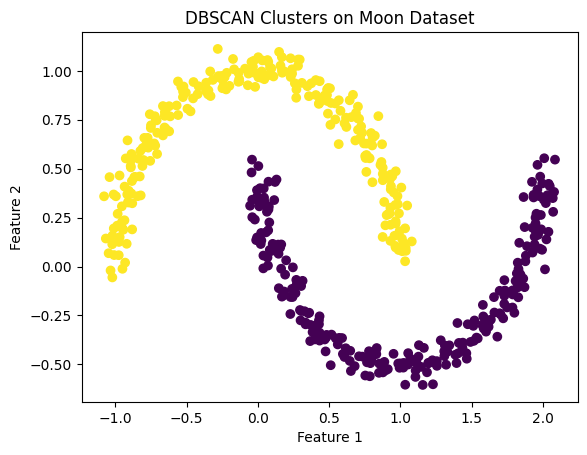

In [ ]:
plt.scatter(df["Feature1"],df["Feature2"],c=df["dbscan_cluster"])

plt.title("DBSCAN Clusters on Moon Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Comparing KMeans vs DBSCAN**

Observations:

1. In the KMeans plot, the dataset is divided into 2 clusters, but the curved moon-shaped data is not separated perfectly because KMeans assumes clusters are circular.
2. In the DBSCAN plot, the two moon-shaped clusters are separated more accurately by grouping points based on their density.
3. DBSCAN follows the natural curved structure of the moon dataset, while KMeans creates straight decision boundaries.
4. If any outlier points are present due to the noise=0.05 setting, DBSCAN identifies them as noise, whereas KMeans assigns every point to one of the two clusters.
5. Visually, the DBSCAN clustering matches the actual shape of the dataset better than KMeans.



Conclusion:
DBSCAN gives better clustering results than KMeans for the moon dataset. It correctly identifies the curved clusters and can detect noise, while KMeans struggles with the non-spherical shape.

In [ ]:
eps_values = [0.2, 0.3, 0.4, 0.5]

results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(x_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = np.sum(labels == -1)

    results.append([eps, n_clusters, noise_points])

results_df = pd.DataFrame(results, columns=["eps", "No. of Clusters", "Noise Points"])
print(results_df)

   eps  No. of Clusters  Noise Points
0  0.2                2             0
1  0.3                2             0
2  0.4                2             0
3  0.5                2             0


All the tested eps values (0.2, 0.3, 0.4, and 0.5) worked equally well for the moon dataset, as each correctly identified 2 clusters with 0 noise points. Since eps = 0.3 was used in the notebook and gave accurate clustering, it can be considered the best choice.

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

x, y_true = make_blobs(n_samples=500, n_features=6, centers=4, random_state=42)

scaler = StandardScaler()
scaled = scaler.fit_transform(x)
scaled[:5]

pd.DataFrame(scaled, columns=["Feature1","Feature2","Feature3","Feature4","Feature5","Feature6"]).head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6
0,-1.152542,0.770706,0.349367,1.069421,-1.638021,1.470515
1,0.104384,-0.991268,0.704397,-0.936032,0.601599,-0.529060
2,-0.156750,1.121362,0.852715,0.719261,-0.212725,-1.417344
3,-1.180125,0.910768,0.101385,1.150839,-1.460057,1.331802
4,-1.482800,0.782397,0.495451,1.086987,-0.745312,1.455738


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled)

data = pd.DataFrame(X_pca, columns=["PC1","PC2"])
print(data.head())

data["Original_Cluster_label"] = y_true

print("Explained Variance Ratio of Two Components :", pca.explained_variance_ratio_)

        PC1       PC2
0  2.509524  1.280952
1 -1.052644 -0.773798
2  1.064574 -1.713426
3  2.429547  1.235971
4  2.317693  0.994984
Explained Variance Ratio of Two Components : [0.67623955 0.21392012]


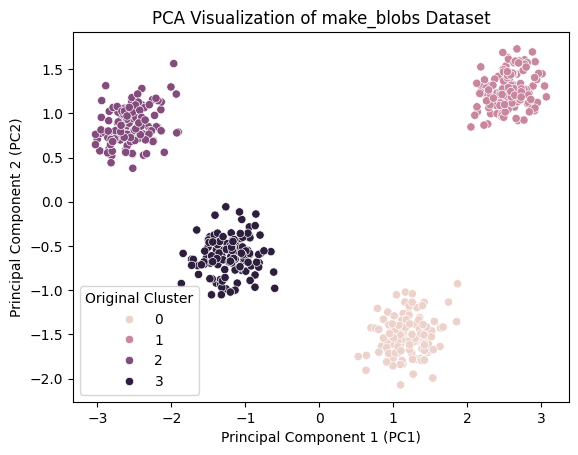

Explained Variance Ratio: [0.67623955 0.21392012]
Total Variance Retained: 0.8901596711868083


In [ ]:
sns.scatterplot(x=data["PC1"], y=data["PC2"], hue=data["Original_Cluster_label"])

plt.title("PCA Visualization of make_blobs Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Original Cluster")
plt.show()
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", pca.explained_variance_ratio_.sum())

In [ ]:
Data = pd.read_csv("./Wine dataset.csv")

num_cols = Data.select_dtypes(include="number").columns
print("Numerical Columns :")
print(num_cols)


Numerical Columns :
Index(['class', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash',
       'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline '],
      dtype='object')


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(Data)
x_scaled[:5]
pd.DataFrame(x_scaled, columns=Data.columns).head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,-1.213944,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,-1.213944,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,-1.213944,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,-1.213944,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,-1.213944,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [ ]:
from sklearn.cluster import DBSCAN

model_dbscan = DBSCAN(eps=0.8, min_samples=5)

Data["cluster"] = model_dbscan.fit_predict(x_scaled)

print(Data["cluster"].value_counts())

cluster
-1    178
Name: count, dtype: int64


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)
X_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
X_pca.head()
X_pca["cluster"] = Data["cluster"]
X_pca.head()

,PC1,PC2,cluster
0,-3.522934,1.453098,-1
1,-2.528858,-0.330019,-1
2,-2.785029,1.036936,-1
3,-3.922588,2.768210,-1
4,-1.407511,0.867773,-1


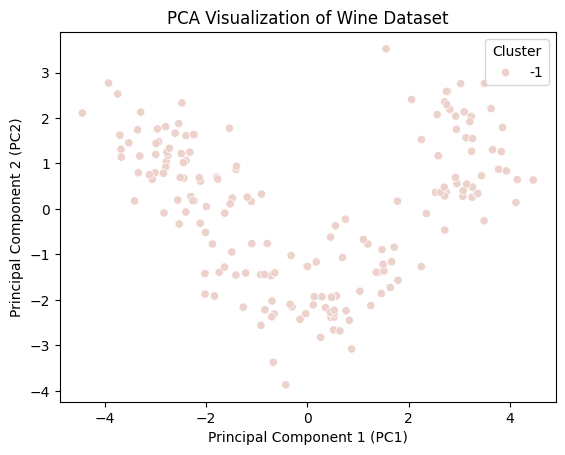

In [ ]:
X_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
X_pca["Cluster"] = labels

sns.scatterplot(data=X_pca, x="PC1", y="PC2", hue="Cluster")

plt.title("PCA Visualization of Wine Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.show()
